In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

In [35]:

df = pd.read_csv("abalone.csv", header=None)

df.columns = [
    "Sex",
    "Length",
    "Diameter",
    "Height",
    "Whole weight",
    "Shucked weight",
    "Viscera weight",
    "Shell weight",
    "Rings"
]

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   str    
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 293.8 KB


In [36]:
df.shape

(4177, 9)

In [37]:
df.head(10)

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7
5,I,0.425,0.300,0.095,0.3515,0.1410,0.0775,0.120,8
6,F,0.530,0.415,0.150,0.7775,0.2370,0.1415,0.330,20
7,F,0.545,0.425,0.125,0.7680,0.2940,0.1495,0.260,16
8,M,0.475,0.370,0.125,0.5095,0.2165,0.1125,0.165,9
9,F,0.550,0.440,0.150,0.8945,0.3145,0.1510,0.320,19


In [38]:
df.tail(10)

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
4167,M,0.500,0.380,0.125,0.5770,0.2690,0.1265,0.1535,9
4168,F,0.515,0.400,0.125,0.6150,0.2865,0.1230,0.1765,8
4169,M,0.520,0.385,0.165,0.7910,0.3750,0.1800,0.1815,10
4170,M,0.550,0.430,0.130,0.8395,0.3155,0.1955,0.2405,10
4171,M,0.560,0.430,0.155,0.8675,0.4000,0.1720,0.2290,8
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10
4176,M,0.710,0.555,0.195,1.9485,0.9455,0.3765,0.4950,12


In [39]:
df.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [40]:
df.isnull().sum()

Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
Rings             0
dtype: int64

In [41]:
df.duplicated().sum()


np.int64(0)

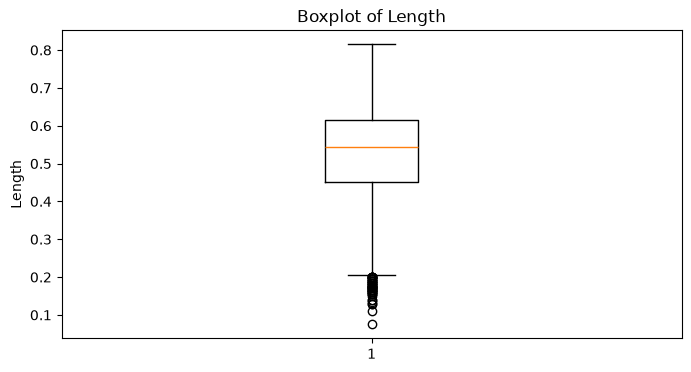

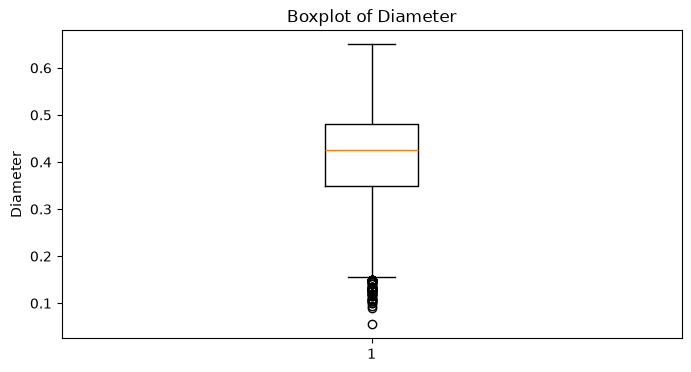

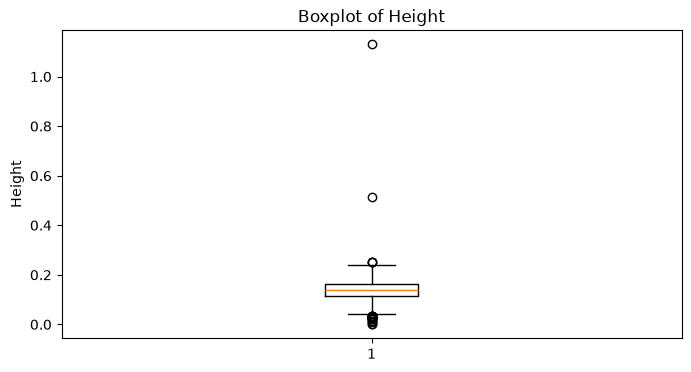

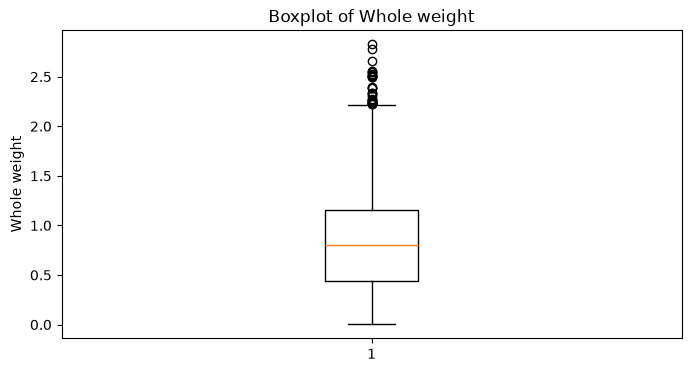

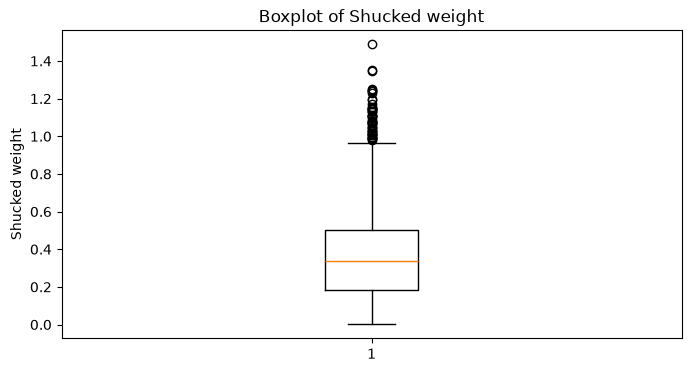

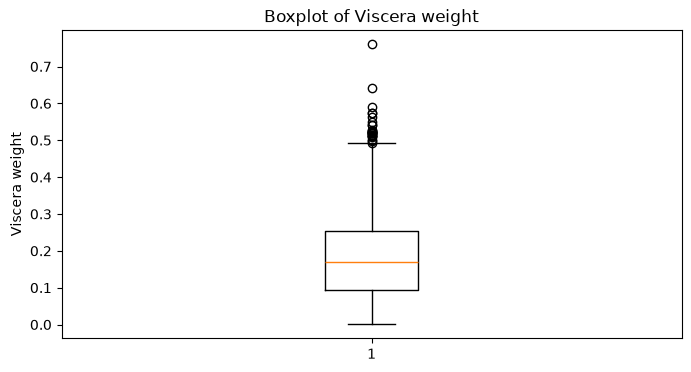

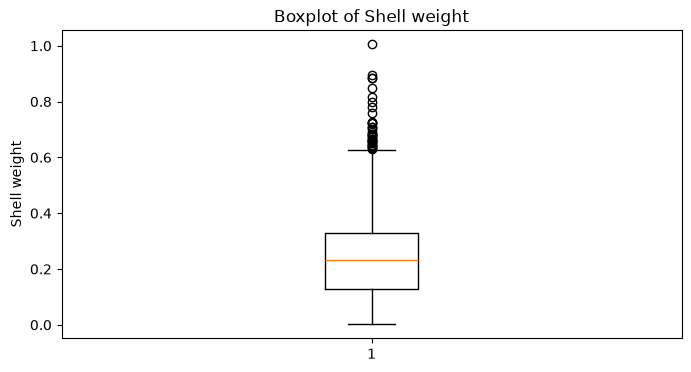

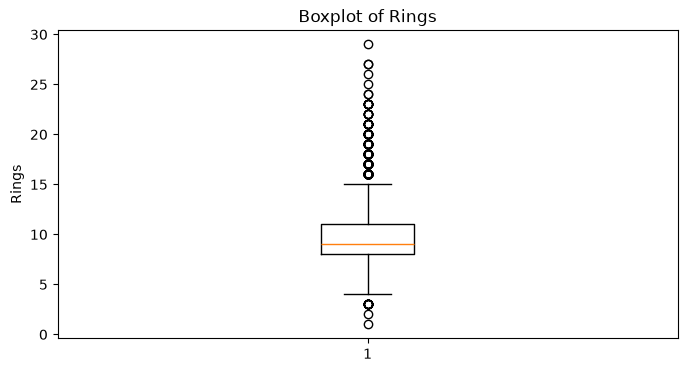

In [42]:
numerical_columns = [
    "Length",
    "Diameter",
    "Height",
    "Whole weight",
    "Shucked weight",
    "Viscera weight",
    "Shell weight",
    "Rings"
]

for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[column])
    plt.title("Boxplot of " + column)
    plt.ylabel(column)
    plt.show()

In [43]:
for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    percentage = (len(outliers) / len(df)) * 100

    print(column, ":", len(outliers), "outliers",
          "(", round(percentage, 2), "% )")

Length : 49 outliers ( 1.17 % )
Diameter : 59 outliers ( 1.41 % )
Height : 29 outliers ( 0.69 % )
Whole weight : 30 outliers ( 0.72 % )
Shucked weight : 48 outliers ( 1.15 % )
Viscera weight : 26 outliers ( 0.62 % )
Shell weight : 35 outliers ( 0.84 % )
Rings : 278 outliers ( 6.66 % )


In [44]:
print(df[df['Height'] > 0.3])
print(df[df['Height'] == 0])

     Sex  Length  Diameter  Height  Whole weight  Shucked weight  \
1417   M   0.705     0.565   0.515         2.210          1.1075   
2051   F   0.455     0.355   1.130         0.594          0.3320   

      Viscera weight  Shell weight  Rings  
1417          0.4865        0.5120     10  
2051          0.1160        0.1335      8  
     Sex  Length  Diameter  Height  Whole weight  Shucked weight  \
1257   I   0.430      0.34     0.0         0.428          0.2065   
3996   I   0.315      0.23     0.0         0.134          0.0575   

      Viscera weight  Shell weight  Rings  
1257          0.0860        0.1150      8  
3996          0.0285        0.3505      6  


In [45]:
df = df.drop(index=[1257, 3996, 1417, 2051]).reset_index(drop=True)

In [46]:
print(df[df['Height'] > 0.3])
print(df[df['Height'] == 0])

Empty DataFrame
Columns: [Sex, Length, Diameter, Height, Whole weight, Shucked weight, Viscera weight, Shell weight, Rings]
Index: []
Empty DataFrame
Columns: [Sex, Length, Diameter, Height, Whole weight, Shucked weight, Viscera weight, Shell weight, Rings]
Index: []


In [47]:
df.shape

(4173, 9)

In [48]:
df = pd.get_dummies(df, columns=['Sex'], drop_first=True)

In [49]:
df.head()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,False,True
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,False,True
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,False,False
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,False,True
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,True,False


In [50]:
df.columns
df[df['Sex_I']==0][df['Sex_M']==0].head()

C:\Users\LOQ\AppData\Local\Temp\ipykernel_24616\3302522961.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['Sex_I']==0][df['Sex_M']==0].head()


,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Sex_I,Sex_M
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.21,9,False,False
6,0.530,0.415,0.150,0.7775,0.2370,0.1415,0.33,20,False,False
7,0.545,0.425,0.125,0.7680,0.2940,0.1495,0.26,16,False,False
9,0.550,0.440,0.150,0.8945,0.3145,0.1510,0.32,19,False,False
10,0.525,0.380,0.140,0.6065,0.1940,0.1475,0.21,14,False,False


In [51]:
X = df.drop(columns=['Rings'])
y = df['Rings']


In [52]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [53]:


model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

print(f"Actual: {y_test.iloc[0]:.0f} rings, Predicted: {y_pred[0]:.2f} rings")

MAE: 1.5841
MSE: 4.9693
RMSE: 2.2292
R²: 0.5853
Actual: 23 rings, Predicted: 16.05 rings


In [54]:

poly = PolynomialFeatures(degree=1, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Polynomial (deg 1) MAE: {mae_poly:.4f}")
print(f"Polynomial (deg 1) MSE: {mse_poly:.4f}")
print(f"Polynomial (deg 1) RMSE: {rmse_poly:.4f}")
print(f"Polynomial (deg 1) R²: {r2_poly:.4f}")
print(f"Feature count after expansion: {X_train_poly.shape[1]}")
print(f"Actual: {y_test.iloc[0]:.0f} rings, Predicted: {y_pred_poly[0]:.2f} rings")

Polynomial (deg 1) MAE: 1.5841
Polynomial (deg 1) MSE: 4.9693
Polynomial (deg 1) RMSE: 2.2292
Polynomial (deg 1) R²: 0.5853
Feature count after expansion: 9
Actual: 23 rings, Predicted: 16.05 rings


In [55]:

poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Polynomial (deg 3) MAE: {mae_poly:.4f}")
print(f"Polynomial (deg 3) MSE: {mse_poly:.4f}")
print(f"Polynomial (deg 3) RMSE: {rmse_poly:.4f}")
print(f"Polynomial (deg 3) R²: {r2_poly:.4f}")
print(f"Feature count after expansion: {X_train_poly.shape[1]}")
print(f"Actual: {y_test.iloc[0]:.0f} rings, Predicted: {y_pred_poly[0]:.2f} rings")

Polynomial (deg 3) MAE: 1.7488
Polynomial (deg 3) MSE: 16.2239
Polynomial (deg 3) RMSE: 4.0279
Polynomial (deg 3) R²: -0.3539
Feature count after expansion: 219
Actual: 23 rings, Predicted: 11.97 rings


In [56]:
poly = PolynomialFeatures(degree=4, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Polynomial (deg 4) MAE: {mae_poly:.4f}")
print(f"Polynomial (deg 4) MSE: {mse_poly:.4f}")
print(f"Polynomial (deg 4) RMSE: {rmse_poly:.4f}")
print(f"Polynomial (deg 4) R²: {r2_poly:.4f}")
print(f"Feature count after expansion: {X_train_poly.shape[1]}")
print(f"Actual: {y_test.iloc[0]:.0f} rings, Predicted: {y_pred_poly[0]:.2f} rings")

Polynomial (deg 4) MAE: 2.1605
Polynomial (deg 4) MSE: 74.6908
Polynomial (deg 4) RMSE: 8.6424
Polynomial (deg 4) R²: -5.2331
Feature count after expansion: 714
Actual: 23 rings, Predicted: 12.47 rings


In [57]:

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Polynomial (deg 2) MAE: {mae_poly:.4f}")
print(f"Polynomial (deg 2) MSE: {mse_poly:.4f}")
print(f"Polynomial (deg 2) RMSE: {rmse_poly:.4f}")
print(f"Polynomial (deg 2) R²: {r2_poly:.4f}")
print(f"Feature count after expansion: {X_train_poly.shape[1]}")
print(f"Actual: {y_test.iloc[0]:.0f} rings, Predicted: {y_pred_poly[0]:.2f} rings")

Polynomial (deg 2) MAE: 1.5223
Polynomial (deg 2) MSE: 4.9282
Polynomial (deg 2) RMSE: 2.2199
Polynomial (deg 2) R²: 0.5887
Feature count after expansion: 54
Actual: 23 rings, Predicted: 15.88 rings


In [58]:
print("Train R²:", r2_score(y_train, poly_model.predict(X_train_poly)))
print("Test R²:", r2_score(y_test, y_pred_poly))

Train R²: 0.5809556854907325
Test R²: 0.5887315355206664


In [59]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest MAE: {mae_rf:.4f}")
print(f"Random Forest MSE: {mse_rf:.4f}")
print(f"Random Forest RMSE: {rmse_rf:.4f}")
print(f"Random Forest R²: {r2_rf:.4f}")

print("Train R²:", r2_score(y_train, rf_model.predict(X_train)))
print("Test R²:", r2_score(y_test, y_pred_rf))

Random Forest MAE: 1.5505
Random Forest MSE: 4.9891
Random Forest RMSE: 2.2336
Random Forest R²: 0.5836
Train R²: 0.9355541838689354
Test R²: 0.5836490308092853


In [60]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Train R²:", r2_score(y_train, rf_model.predict(X_train)))
print("Test R²:", r2_score(y_test, y_pred_rf))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Train R²: 0.7046384148952491
Test R²: 0.5970971326469057
Test RMSE: 2.197255382697872


In [61]:
dt_model = DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Train R²:", r2_score(y_train, dt_model.predict(X_train)))
print("Test R²:", r2_score(y_test, y_pred_dt))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))

Train R²: 0.67471758352381
Test R²: 0.5035730568956676
Test RMSE: 2.4389788269381585


In [62]:
xgb_model = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("Train R²:", r2_score(y_train, xgb_model.predict(X_train)))
print("Test R²:", r2_score(y_test, y_pred_xgb))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

Train R²: 0.7357531189918518
Test R²: 0.5980446338653564
Test RMSE: 2.194670125030784


In [63]:
results = {
    "Linear Regression": (y_test, model.predict(X_test)),
    "Polynomial (deg 2)": (y_test, poly_model.predict(X_test_poly)),
    "Random Forest (tuned)": (y_test, rf_model.predict(X_test)),
    "Decision Tree": (y_test, dt_model.predict(X_test)),
    "XGBoost": (y_test, xgb_model.predict(X_test)),
}

print(f"{'Model':<25}{'MAE':<10}{'MSE':<10}{'RMSE':<10}{'R²':<10}")
print("-" * 65)
for name, (y_true, y_pred) in results.items():
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{name:<25}{mae:<10.4f}{mse:<10.4f}{rmse:<10.4f}{r2:<10.4f}")

Model                    MAE       MSE       RMSE      R²        
-----------------------------------------------------------------
Linear Regression        1.5841    4.9693    2.2292    0.5853    
Polynomial (deg 2)       1.5223    4.9282    2.2199    0.5887    
Random Forest (tuned)    1.5093    4.8279    2.1973    0.5971    
Decision Tree            1.6932    5.9486    2.4390    0.5036    
XGBoost                  1.5097    4.8166    2.1947    0.5980    


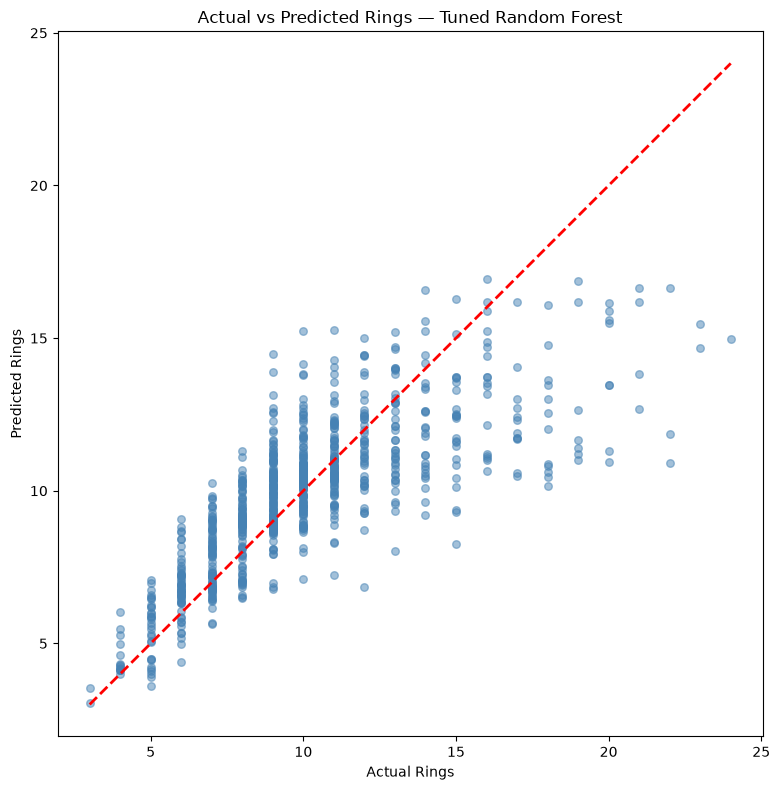

In [64]:
plt.figure(figsize=(8,8))
plt.scatter(y_test, rf_model.predict(X_test), alpha=0.5, s=30, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.title("Actual vs Predicted Rings — Tuned Random Forest")
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

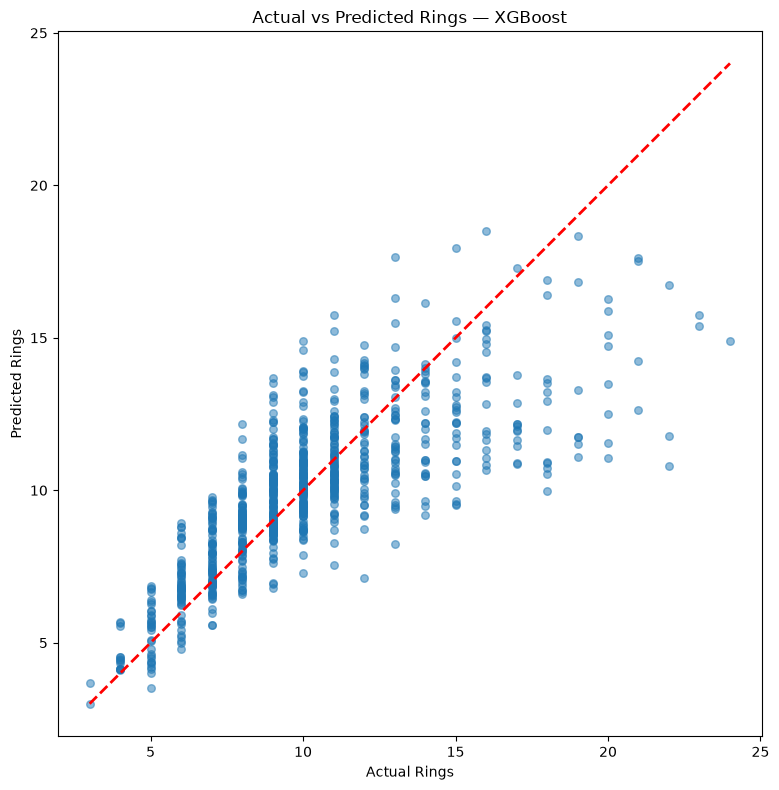

In [65]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    xgb_model.predict(X_test),
    alpha=0.5,
    s=30
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.title("Actual vs Predicted Rings — XGBoost")

plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()